# Jupyter Notebook报错排查

`import sys`  
`print(sys.executable)`

#### 首先激活环境
`conda activate your_environment  # Windows`  
`source activate your_environment  # macOS/Linux`

#### 安装ipykernel
`pip install ipykernel`

#### 添加内核到 Jupyter
`python -m ipykernel install --user --name your_environment --display-name "Python (your_environment)"`

# Import packages

In [4]:
import torch, cv2, os, sys, numpy as np, matplotlib.pyplot as plt
from PIL import Image

# Load model codes and model files

In [5]:
sys.path.append('./LAM_Demo')
from ModelZoo.utils import load_as_tensor, Tensor2PIL, PIL2Tensor, _add_batch_one
from ModelZoo import get_model, load_model, print_network
from SaliencyModel.utils import vis_saliency, vis_saliency_kde, click_select_position, grad_abs_norm, grad_norm, \
    prepare_images, make_pil_grid, blend_input
from SaliencyModel.utils import cv2_to_pil, pil_to_cv2, gini
from SaliencyModel.attributes import attr_grad
from SaliencyModel.BackProp import I_gradient, attribution_objective, Path_gradient
from SaliencyModel.BackProp import saliency_map_PG as saliency_map
from SaliencyModel.BackProp import GaussianBlurPath
from SaliencyModel.utils import grad_norm, IG_baseline, interpolation, isotropic_gaussian_kernel
import ModelZoo
import ModelZoo.utils
import SaliencyModel.utils
import SaliencyModel.BackProp
import SaliencyModel.attributes

# Load SR Network

In [6]:
model = ModelZoo.load_model('HAT@Base')  # You can Change the model name to load different models

Getting SR Network HAT


C:\software\anaconda3\envs\python3.9\lib\site-packages\torch\functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Network [HAT] was created. Total number of parameters: 20772.5 kelo. To see the architecture, do print(network).
Loading model LAM_Demo\ModelZoo\models\HAT_SRx4.pth for HAT network.


# Load test image
We provide 7 images for testing demo

[![1](./LAM_Demo/test_images/1.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/1.png?raw=true)
[![2](./LAM_Demo/test_images/2.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/2.png?raw=true)
[![3](./LAM_Demo/test_images/3.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/3.png?raw=true)
[![4](./LAM_Demo/test_images/4.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/4.png?raw=true)
[![5](./LAM_Demo/test_images/5.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/5.png?raw=true)
[![6](./LAM_Demo/test_images/6.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/6.png?raw=true)
[![7](./LAM_Demo/test_images/7.png)](https://github.com/X-Lowlevel-Vision/LAM_Demo/blob/main/test_images/7.png?raw=true)

Their name is :　`1.png`, `2.png`, `3.png`, `4.png`, `5.png`, `6.png`, `7.png`

In [7]:
window_size = 16  # Define windoes_size of D
img_lr, img_hr = SaliencyModel.utils.prepare_images('./LAM_Demo/test_images/7.png')  # Change this image name
tensor_lr = ModelZoo.utils.PIL2Tensor(img_lr)[:3]
tensor_hr = ModelZoo.utils.PIL2Tensor(img_hr)[:3]
cv2_lr = np.moveaxis(tensor_lr.numpy(), 0, 2)
cv2_hr = np.moveaxis(tensor_hr.numpy(), 0, 2)

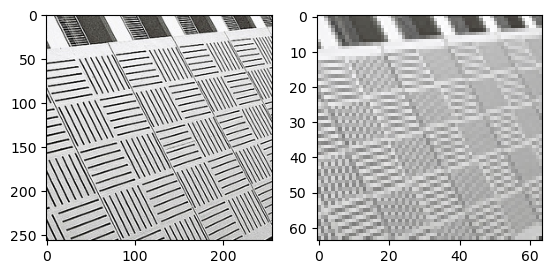

In [8]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(cv2_hr)
axes[1].imshow(cv2_lr)

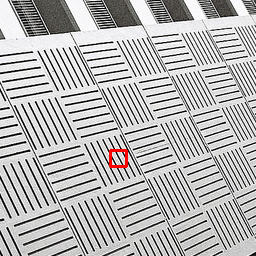

In [9]:
w = 110  # The x coordinate of your select patch, 110 as an example
h = 150  # The y coordinate of your select patch, 150 as an example
# And check the red box
# Is your selected patch this one? If not, adjust the `w` and `h`.


draw_img = SaliencyModel.utils.pil_to_cv2(img_hr)
cv2.rectangle(draw_img, (w, h), (w + window_size, h + window_size), (0, 0, 255), 2)
position_pil = SaliencyModel.utils.cv2_to_pil(draw_img)
position_pil

# Calculate the Local Attribution Maps

This also may take a while

In [10]:
sigma = 1.2
fold = 50
l = 9
alpha = 0.5
attr_objective = SaliencyModel.BackProp.attribution_objective(attr_grad, h, w, window=window_size)
gaus_blur_path_func = SaliencyModel.BackProp.GaussianBlurPath(sigma, fold, l)
interpolated_grad_numpy, result_numpy, interpolated_numpy = SaliencyModel.BackProp.Path_gradient(tensor_lr.numpy(),
                                                                                                 model, attr_objective,
                                                                                                 gaus_blur_path_func,
                                                                                                 cuda=True)
grad_numpy, result = SaliencyModel.BackProp.saliency_map_PG(interpolated_grad_numpy, result_numpy)
abs_normed_grad_numpy = SaliencyModel.utils.grad_abs_norm(grad_numpy)
saliency_image_abs = SaliencyModel.utils.vis_saliency(abs_normed_grad_numpy, zoomin=4)
saliency_image_kde = SaliencyModel.utils.vis_saliency_kde(abs_normed_grad_numpy)
blend_abs_and_input = SaliencyModel.utils.cv2_to_pil(
    pil_to_cv2(saliency_image_abs) * (1.0 - alpha) + pil_to_cv2(img_lr.resize(img_hr.size)) * alpha)
blend_kde_and_input = SaliencyModel.utils.cv2_to_pil(
    pil_to_cv2(saliency_image_kde) * (1.0 - alpha) + pil_to_cv2(img_lr.resize(img_hr.size)) * alpha)
pil = SaliencyModel.utils.make_pil_grid([position_pil, saliency_image_abs, blend_abs_and_input, blend_kde_and_input,
                                         ModelZoo.utils.Tensor2PIL(torch.clamp(torch.tensor(result), min=0., max=1.))])

# Analyze the results
From left to right, the images are:
1. The original image with the selected region
2. The LAM result
3. The LAM result with the input image
4. The informative area with the input image
5. The super-resolved image

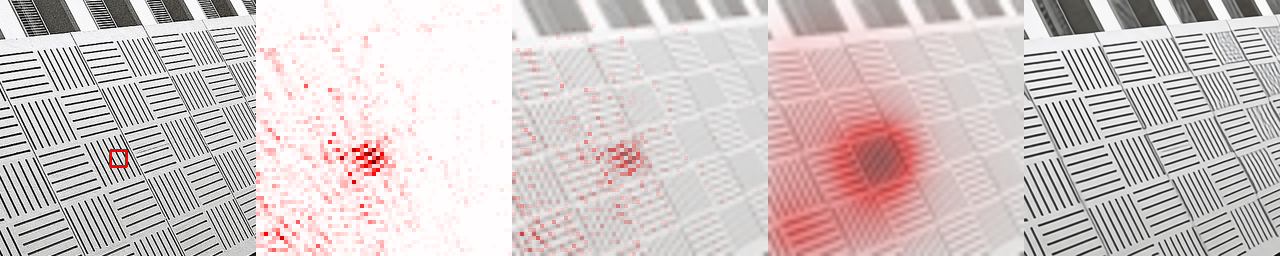

In [11]:
pil

# Calculate the Diffusion Index

In [12]:
gini_index = SaliencyModel.utils.gini(abs_normed_grad_numpy)
diffusion_index = (1 - gini_index) * 100
print(f"The DI of this case is {diffusion_index}")

The DI of this case is 25.435017131303063
